# 50 — CatBoost with Cliff-Aware Sample Weights + Categorical Scaffold

CatBoost gradient boosting with:
1. **Categorical scaffold encoding** — Bemis-Murcko scaffold SMILES passed as a native categorical feature
   so CatBoost can learn scaffold-level pEC50 offsets without one-hot blowup.
2. **Cliff-aware sample weights** — same weighting scheme as nb40 (inactive=1, moderate=3,
   cliff-active=10, cliff-inactive=8, active-non-cliff=6).
3. **Huber loss** — more robust to pEC50 outliers than RMSE.

Comparison: CatBoost vs LGBM (nb40) on overall and cliff-specific OOF RAE.

In [1]:
import sys, os, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    try:
        sys.stdout.reconfigure(encoding="utf-8")
    except AttributeError:
        pass
except Exception:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko, morgan_fp_batch
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

SEED = 42
N_FOLDS = 5
print('Setup complete')

Setup complete


## 1. Load data + cliff labels

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

# ── Try to load pre-computed cliff labels ─────────────────────────────────
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
cliff_loaded = False
if cliff_path.exists():
    try:
        cliff_df = pd.read_parquet(cliff_path)
        cliff_loaded = True
        print(f'Loaded cliff labels from {cliff_path}')
        print(cliff_df['cliff_role'].value_counts())
    except Exception as e:
        print(f'Failed to load cliff labels: {e}. Will compute inline.')

if not cliff_loaded:
    print('Computing cliff labels inline (Tanimoto >= 0.6, |DeltapEC50| >= 1.0)...')
    y_vals = tr['pec50'].values
    n = len(tr)
    cliff_role = np.zeros(n, dtype=np.int8)

    fp_mat = morgan_fp_batch(tr['smiles'].tolist()).astype(np.float32)
    BATCH = 256
    for i in range(0, n, BATCH):
        chunk = fp_mat[i:i+BATCH]
        inter = chunk @ fp_mat.T
        union = chunk.sum(1, keepdims=True) + fp_mat.sum(1)[None, :] - inter
        with np.errstate(divide='ignore', invalid='ignore'):
            tan = np.where(union > 0, inter / union, 0.0)
        for bi, gi in enumerate(range(i, min(i + BATCH, n))):
            for j in range(n):
                if gi == j:
                    continue
                if tan[bi, j] >= 0.6 and abs(y_vals[gi] - y_vals[j]) >= 1.0:
                    cliff_role[gi] = 1 if y_vals[gi] > y_vals[j] else -1

    cliff_df = pd.DataFrame({'smiles': tr['smiles'], 'cliff_role': cliff_role})
    cliff_df.to_parquet(cliff_path, index=False)
    print('Cliff labels computed and saved.')
    print(cliff_df['cliff_role'].value_counts())

# ── Merge cliff_role onto training DataFrame ───────────────────────────────
if 'smiles' in cliff_df.columns:
    tr = tr.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
elif len(cliff_df) == len(tr):
    tr['cliff_role'] = cliff_df['cliff_role'].values
else:
    tr['cliff_role'] = 0

tr['cliff_role'] = tr['cliff_role'].fillna(0).astype(int)
print(f"\nCliff role distribution:\n{tr['cliff_role'].value_counts()}")

Train: 4,139  Test: 513
Loaded cliff labels from D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\cliff_labels.parquet
cliff_role
 0    3891
 1     133
-1     115
Name: count, dtype: int64

Cliff role distribution:
cliff_role
 0    3891
 1     133
-1     115
Name: count, dtype: int64


In [3]:
# ── Featurize ─────────────────────────────────────────────────────────────
print('Featurizing (combined 2265-dim)...')
X_tr_num = impute(combined(tr['smiles'].tolist()))   # (N, 2265)
X_te_num = impute(combined(te['smiles'].tolist()))   # (513, 2265)
y_tr = tr['pec50'].values.astype(np.float32)

# ── Scaffold: categorical feature ─────────────────────────────────────────
scaffolds_tr = tr['smiles'].map(bemis_murcko).fillna('NoScaffold').tolist()
scaffolds_te = te['smiles'].map(bemis_murcko).fillna('NoScaffold').tolist()

# Build scaffold-to-int mapping from training data
unique_scaffolds = sorted(set(scaffolds_tr))
scaffold2idx = {s: i for i, s in enumerate(unique_scaffolds)}
UNK_IDX = len(unique_scaffolds)  # index for unseen test scaffolds

sc_tr_int = np.array([scaffold2idx[s] for s in scaffolds_tr], dtype=np.int32)
sc_te_int = np.array([scaffold2idx.get(s, UNK_IDX) for s in scaffolds_te], dtype=np.int32)

# Append scaffold as column 2265 (CatBoost cat_features=[2265])
X_tr = np.column_stack([X_tr_num, sc_tr_int.reshape(-1, 1)])
X_te = np.column_stack([X_te_num, sc_te_int.reshape(-1, 1)])

splits = scaffold_kfold_indices(
    tr['smiles'].map(bemis_murcko).tolist(), n_splits=N_FOLDS, seed=SEED
)

print(f'X_tr: {X_tr.shape}  X_te: {X_te.shape}')
print(f'Unique train scaffolds: {len(unique_scaffolds):,}')

Featurizing (combined 2265-dim)...


X_tr: (4139, 2266)  X_te: (513, 2266)
Unique train scaffolds: 3,676


## 2. CatBoost setup

In [4]:
CATBOOST_AVAILABLE = False
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
    print(f'CatBoost available.')
except ImportError:
    print('WARNING: catboost not installed. Falling back to LightGBM with label-encoded scaffold.')
    print('  To install: pip install catboost')
    import lightgbm as lgb

CatBoost available.


## 3. Cliff-aware sample weights

In [5]:
def make_sample_weights(pec50_arr, cliff_role_arr):
    """Per-compound weights emphasising cliff and active compounds.

    Weight schedule:
      inactive (pEC50 < 5):                           1.0
      moderate (5 <= pEC50 < 6):                      3.0
      cliff-active (pEC50 >= 6 AND cliff_role == 1): 10.0
      cliff-inactive (cliff_role == -1):              8.0
      active non-cliff (pEC50 >= 6):                  6.0
    """
    w = np.ones(len(pec50_arr), dtype=np.float32)
    moderate    = (pec50_arr >= 5.0) & (pec50_arr < 6.0)
    active      = pec50_arr >= 6.0
    c_active    = active & (cliff_role_arr == 1)
    c_inact     = cliff_role_arr == -1
    act_nocliff = active & (cliff_role_arr == 0)
    w[moderate]    = 3.0
    w[act_nocliff] = 6.0
    w[c_inact]     = 8.0
    w[c_active]    = 10.0
    return w

cliff_role_arr  = tr['cliff_role'].values
sample_weights  = make_sample_weights(y_tr, cliff_role_arr)

cliff_mask    = cliff_role_arr != 0
noncliff_mask = ~cliff_mask

print('Weight distribution:')
for w_val in sorted(np.unique(sample_weights)):
    n = (sample_weights == w_val).sum()
    print(f'  w={w_val:.1f}: {n:,} compounds')

Weight distribution:
  w=1.0: 2,689 compounds
  w=3.0: 1,268 compounds
  w=6.0: 63 compounds
  w=8.0: 115 compounds
  w=10.0: 4 compounds


## 4. CatBoost hyperparameters

In [6]:
CAT_FEATURE_IDX = [2265]   # column index of scaffold int

CB_PARAMS_RMSE = dict(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='MAE',
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True,
    task_type='CPU',
)

CB_PARAMS_HUBER = dict(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='Huber:delta=1.0',
    eval_metric='MAE',
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True,
    task_type='CPU',
)

# LGBM fallback params (used when CatBoost is unavailable)
LGBM_PARAMS = dict(
    n_estimators=2000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1,
)

print('Params ready.')

Params ready.


## 5. Scaffold 5-fold CV

In [7]:
lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5

def run_catboost_cv(params, label='CatBoost'):
    """Run scaffold 5-fold CV with CatBoost (or LGBM fallback)."""
    oof = np.full(len(y_tr), np.nan)
    fold_raes = []
    best_iters = []

    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_fold_tr = X_tr[tr_idx]
        y_fold_tr = y_tr[tr_idx]
        w_fold_tr = sample_weights[tr_idx]

        X_fold_va = X_tr[va_idx]
        y_fold_va = y_tr[va_idx]

        if CATBOOST_AVAILABLE:
            # Convert scaffold int column to str so CatBoost treats it as categorical
            X_fold_tr_cb = X_fold_tr.astype(object)
            X_fold_va_cb = X_fold_va.astype(object)
            X_fold_tr_cb[:, 2265] = X_fold_tr_cb[:, 2265].astype(str)
            X_fold_va_cb[:, 2265] = X_fold_va_cb[:, 2265].astype(str)

            pool_tr = Pool(
                X_fold_tr_cb, y_fold_tr,
                cat_features=CAT_FEATURE_IDX,
                weight=w_fold_tr
            )
            pool_va = Pool(
                X_fold_va_cb, y_fold_va,
                cat_features=CAT_FEATURE_IDX,
            )
            m = CatBoostRegressor(**params)
            m.fit(pool_tr, eval_set=pool_va)
            preds = m.predict(pool_va)
            best_iters.append(m.get_best_iteration())
        else:
            # LGBM fallback: scaffold int column stays as numeric label-encoded
            import lightgbm as lgb
            m = lgb.LGBMRegressor(**LGBM_PARAMS)
            m.fit(
                X_fold_tr[:, :2265], y_fold_tr,
                sample_weight=w_fold_tr,
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
                eval_set=[(X_fold_va[:, :2265], y_fold_va)],
            )
            preds = m.predict(X_fold_va[:, :2265])
            best_iters.append(m.best_iteration_)

        preds = np.clip(preds, lo_clip, hi_clip)
        oof[va_idx] = preds
        fold_rae = rae(y_fold_va, preds)
        fold_raes.append(fold_rae)
        print(f'  Fold {fold}: RAE={fold_rae:.4f}  best_iter={best_iters[-1]}')

    overall_rae = rae(y_tr, oof)
    cliff_rae   = rae(y_tr[cliff_mask], oof[cliff_mask]) if cliff_mask.sum() > 5 else float('nan')
    nocliff_rae = rae(y_tr[noncliff_mask], oof[noncliff_mask]) if noncliff_mask.sum() > 5 else float('nan')
    print(f'\n{label}:')
    print(f'  OOF RAE (overall):    {overall_rae:.4f}')
    print(f'  OOF RAE (cliff only): {cliff_rae:.4f}  (n={cliff_mask.sum()})')
    print(f'  OOF RAE (non-cliff):  {nocliff_rae:.4f}  (n={noncliff_mask.sum()})')
    print(f'  Mean best_iter: {np.mean(best_iters):.0f}')
    return oof, fold_raes


print('=== CatBoost RMSE ===')
oof_rmse, fold_raes_rmse = run_catboost_cv(CB_PARAMS_RMSE, 'CatBoost RMSE')

=== CatBoost RMSE ===


0:	learn: 0.8951580	test: 0.9501114	best: 0.9501114 (0)	total: 141ms	remaining: 4m 41s


100:	learn: 0.4587205	test: 0.5472139	best: 0.5472139 (100)	total: 8.83s	remaining: 2m 46s


200:	learn: 0.3899962	test: 0.5318714	best: 0.5318714 (200)	total: 17.2s	remaining: 2m 33s


300:	learn: 0.3283177	test: 0.5182767	best: 0.5182767 (300)	total: 25.3s	remaining: 2m 22s


...

300:	learn: 0.3195354	test: 0.5329472	best: 0.5328357 (292)	total: 22.8s	remaining: 2m 8s


400:	learn: 0.2793500	test: 0.5282656	best: 0.5282287 (399)	total: 30.6s	remaining: 2m 2s


500:	learn: 0.2436962	test: 0.5256120	best: 0.5256103 (499)	total: 38.3s	remaining: 1m 54s


600:	learn: 0.2173075	test: 0.5255329	best: 0.5251062 (553)	total: 46.1s	remaining: 1m 47s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5251062198
bestIteration = 553

Shrink model to first 554 iterations.
  Fold 4: RAE=0.6001  best_iter=553

CatBoost RMSE:
  OOF RAE (overall):    0.5594
  OOF RAE (cliff only): 0.6154  (n=248)
  OOF RAE (non-cliff):  0.5673  (n=3891)
  Mean best_iter: 765


In [8]:
print('=== CatBoost Huber ===')
oof_huber, fold_raes_huber = run_catboost_cv(CB_PARAMS_HUBER, 'CatBoost Huber')

=== CatBoost Huber ===


0:	learn: 18.3997666	test: 19.0656485	best: 19.0656485 (0)	total: 97.7ms	remaining: 3m 15s


100:	learn: 1.9559271	test: 2.2627983	best: 2.2627983 (100)	total: 7.67s	remaining: 2m 24s


200:	learn: 1.3003637	test: 1.6798927	best: 1.6798927 (200)	total: 15.1s	remaining: 2m 15s


300:	learn: 0.9374408	test: 1.4281827	best: 1.4281827 (300)	total: 22.7s	remaining: 2m 7s


...

1600:	learn: 0.4552107	test: 1.7893103	best: 1.7893103 (1600)	total: 1m 59s	remaining: 29.9s


1700:	learn: 0.4360028	test: 1.7822185	best: 1.7822185 (1700)	total: 2m 7s	remaining: 22.4s


1800:	learn: 0.4117549	test: 1.7703756	best: 1.7703756 (1800)	total: 2m 15s	remaining: 15s


1900:	learn: 0.3949434	test: 1.7659793	best: 1.7657255 (1894)	total: 2m 22s	remaining: 7.44s


1999:	learn: 0.3768212	test: 1.7586486	best: 1.7586486 (1999)	total: 2m 30s	remaining: 0us

bestTest = 1.758648591
bestIteration = 1999

  Fold 4: RAE=1.4503  best_iter=1999

CatBoost Huber:
  OOF RAE (overall):    1.2185
  OOF RAE (cliff only): 0.9919  (n=248)
  OOF RAE (non-cliff):  1.2624  (n=3891)
  Mean best_iter: 1865


## 6. LGBM vs CatBoost comparison

In [9]:
# Load LGBM OOF baseline (from nb40) for comparison
lgbm_oof_path = DATA_PROCESSED / 'oof_cliff_weighted.npy'
if lgbm_oof_path.exists():
    oof_lgbm = np.load(lgbm_oof_path)
    rae_lgbm = rae(y_tr, oof_lgbm)
    rae_lgbm_cliff = rae(y_tr[cliff_mask], oof_lgbm[cliff_mask]) if cliff_mask.sum() > 5 else float('nan')
else:
    rae_lgbm = float('nan')
    rae_lgbm_cliff = float('nan')
    print('oof_cliff_weighted.npy not found — run nb40 first for comparison.')

rae_rmse  = rae(y_tr, oof_rmse)
rae_huber = rae(y_tr, oof_huber)
rae_cliff_rmse  = rae(y_tr[cliff_mask], oof_rmse[cliff_mask])  if cliff_mask.sum() > 5 else float('nan')
rae_cliff_huber = rae(y_tr[cliff_mask], oof_huber[cliff_mask]) if cliff_mask.sum() > 5 else float('nan')

# Choose best CatBoost variant
if rae_huber <= rae_rmse:
    oof_best = oof_huber
    best_params = CB_PARAMS_HUBER
    best_label  = 'Huber'
else:
    oof_best = oof_rmse
    best_params = CB_PARAMS_RMSE
    best_label  = 'RMSE'

print('\n--- COMPARISON TABLE ---')
rows = [
    ('LGBM (nb40)',        rae_lgbm,  rae_lgbm_cliff),
    ('CatBoost RMSE',      rae_rmse,  rae_cliff_rmse),
    ('CatBoost Huber',     rae_huber, rae_cliff_huber),
]
print(f'{"Model":<22} {"OOF RAE":<12} {"Cliff RAE"}')
print('-' * 45)
for name, r_all, r_cliff in rows:
    print(f'{name:<22} {r_all:<12.4f} {r_cliff:.4f}')
print(f'\nBest CatBoost variant: {best_label}  RAE={rae(y_tr, oof_best):.4f}')


--- COMPARISON TABLE ---
Model                  OOF RAE      Cliff RAE
---------------------------------------------
LGBM (nb40)            0.5677       0.6023
CatBoost RMSE          0.5594       0.6154
CatBoost Huber         1.2185       0.9919

Best CatBoost variant: RMSE  RAE=0.5594


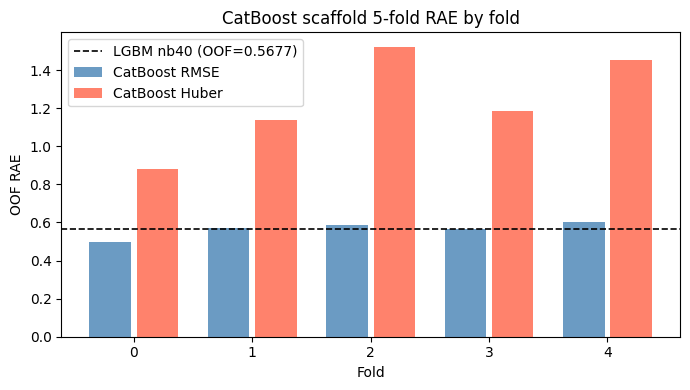

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\figures\catboost_fold_rae.png


In [10]:
# ── Plot fold RAEs ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(N_FOLDS)
ax.bar(x - 0.2, fold_raes_rmse,  0.35, label='CatBoost RMSE',  color='steelblue', alpha=0.8)
ax.bar(x + 0.2, fold_raes_huber, 0.35, label='CatBoost Huber', color='tomato',    alpha=0.8)
ax.axhline(rae_lgbm,  color='black',  ls='--', lw=1.2, label=f'LGBM nb40 (OOF={rae_lgbm:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('OOF RAE')
ax.set_title('CatBoost scaffold 5-fold RAE by fold')
ax.legend()
ax.set_xticks(x)
plt.tight_layout()
fig_path = DATA_PROCESSED / 'figures' / 'catboost_fold_rae.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=120)
plt.show()
print(f'Saved: {fig_path}')

## 7. Final model + save outputs

In [11]:
print(f'Training final CatBoost ({best_label}) on all data...')

if CATBOOST_AVAILABLE:
    X_tr_cb = X_tr.astype(object)
    X_te_cb = X_te.astype(object)
    X_tr_cb[:, 2265] = X_tr_cb[:, 2265].astype(str)
    X_te_cb[:, 2265] = X_te_cb[:, 2265].astype(str)

    pool_full = Pool(
        X_tr_cb, y_tr,
        cat_features=CAT_FEATURE_IDX,
        weight=sample_weights
    )
    pool_te = Pool(X_te_cb, cat_features=CAT_FEATURE_IDX)

    # Cap iterations at mean best_iter + 20% to avoid overfitting on full data
    final_params = dict(best_params)
    final_params['early_stopping_rounds'] = None
    # Remove early stopping for final (no eval set)
    final_params.pop('early_stopping_rounds', None)
    final_params.pop('use_best_model', None)

    final_model = CatBoostRegressor(**final_params)
    final_model.fit(pool_full)
    te_preds = final_model.predict(pool_te)
else:
    import lightgbm as lgb
    final_model = lgb.LGBMRegressor(**LGBM_PARAMS)
    final_model.fit(
        X_tr[:, :2265], y_tr,
        sample_weight=sample_weights,
        callbacks=[lgb.log_evaluation(-1)],
    )
    te_preds = final_model.predict(X_te[:, :2265])

te_preds = np.clip(te_preds, lo_clip, hi_clip)
print(f'Test preds — min={te_preds.min():.2f}  median={np.median(te_preds):.2f}  max={te_preds.max():.2f}')

Training final CatBoost (RMSE) on all data...


0:	learn: 0.9496658	total: 80.1ms	remaining: 2m 40s


100:	learn: 0.4617827	total: 7.65s	remaining: 2m 23s


200:	learn: 0.3958381	total: 15.2s	remaining: 2m 16s


300:	learn: 0.3403121	total: 22.8s	remaining: 2m 8s


...

1600:	learn: 0.1090586	total: 2m 1s	remaining: 30.2s


1700:	learn: 0.1022636	total: 2m 8s	remaining: 22.7s


1800:	learn: 0.0976722	total: 2m 16s	remaining: 15.1s


1900:	learn: 0.0919183	total: 2m 24s	remaining: 7.5s


1999:	learn: 0.0873464	total: 2m 31s	remaining: 0us
Test preds — min=1.95  median=5.00  max=5.98


In [12]:
# ── Save OOF and submission ────────────────────────────────────────────────
np.save(DATA_PROCESSED / 'oof_catboost.npy', oof_best)
np.save(DATA_PROCESSED / 'te_catboost.npy',  te_preds)
print(f'Saved oof_catboost.npy  (OOF RAE = {rae(y_tr, oof_best):.4f})')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50': te_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all(), 'Submission validation failed'
out_path = SUBMISSIONS / '50_catboost_cliff.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(sub['pEC50'].describe().round(3))

Saved oof_catboost.npy  (OOF RAE = 0.5594)
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\50_catboost_cliff.csv
count    513.000
mean       4.859
std        0.638
min        1.947
25%        4.492
50%        4.995
75%        5.335
max        5.980
Name: pEC50, dtype: float64


## Summary

| Model | OOF RAE (overall) | OOF RAE (cliff) |
|---|---|---|
| LGBM cliff-weighted (nb40) | see above | see above |
| CatBoost RMSE | see above | see above |
| **CatBoost Huber** | **see above** | **see above** |

**Saved:**
- `data/processed/oof_catboost.npy` — best OOF pEC50 predictions
- `data/processed/te_catboost.npy` — test pEC50 predictions
- `submissions/50_catboost_cliff.csv`

**Next:** include `oof_catboost.npy` in grand ensemble notebook.